# Stage Routing in a Square Room

This notebook demonstrates three routing variants in the same $10 \times 10$ room:

- Scenario 1: `distribution -> waiting stage -> stage -> exit`
- Scenario 2: `distribution -> waiting stage -> exit`
- Scenario 3: `distribution -> exit`

The scenario is loaded from [`scenarios/stage-routing-square-room`](scenarios/stage-routing-square-room).

In [ ]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pedpy

from core.scenario import Scenario, load_scenario, run_scenario

In [ ]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.edgecolor": "#444444",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "xtick.color": "#222222",
        "ytick.color": "#222222",
        "font.size": 11,
    }
)

COLORS = {
    "scenario_1": "#4C72B0",
    "scenario_2": "#DD8452",
    "scenario_3": "#55A868",
}

LABELS = {
    "scenario_1": "Wait 5 s at stage 1, then visit stage 2",
    "scenario_2": "Wait 5 s at stage 1, then go to exit",
    "scenario_3": "Directly go to exit",
}


## Load the Base Scenario

The scenario directory already contains the room geometry, the start distribution, the exit, and both stages. We then clone the loaded scenario data before changing the journey definitions so each routing variant stays independent.

In [ ]:
SCENARIO_DIR = Path("scenarios") / "stage-routing-square-room"
base_scenario = load_scenario(str(SCENARIO_DIR))
print(base_scenario.summary())

In [ ]:
def clone_scenario(base: Scenario, raw: dict, name: str) -> Scenario:
    sim_params = raw.get("config", {})\
        .get("simulation_settings", {})\
        .get("simulationParams", base.sim_params)
    return Scenario(
        raw=raw,
        walkable_area_wkt=base.walkable_area_wkt,
        model_type=sim_params.get("model_type", base.model_type),
        seed=raw.get("config", {})
        .get("simulation_settings", {})
        .get("baseSeed", base.seed),
        sim_params=deepcopy(sim_params),
        source_path=name,
    )


def make_variant(base: Scenario, name: str, stages: list[str]) -> Scenario:
    raw = deepcopy(base.raw)
    raw["journeys"] = [
        {
            "id": "jps-journeys_0",
            "stages": ["jps-distributions_0", *stages, "jps-exits_0"],
        }
    ]
    return clone_scenario(base, raw, name)


def add_room_markers(ax):
    overlays = [
        (patches.Rectangle((3.2, -0.9), 1.6, 1.8, facecolor="#CFE8FF", edgecolor="#4C72B0", linewidth=1.5), "Start", (4.0, 1.15)),
        (patches.Rectangle((-4.35, -0.85), 0.7, 1.7, facecolor="#D6F5D6", edgecolor="#55A868", linewidth=1.5), "Exit", (-4.0, 1.15)),
        (patches.Rectangle((-0.55, 3.45), 1.1, 1.1, facecolor="#FCE3C1", edgecolor="#DD8452", linewidth=1.5), "Stage 1\n(wait 5 s)", (0.0, 4.95)),
        (patches.Rectangle((-0.55, -4.55), 1.1, 1.1, facecolor="#E7D9F7", edgecolor="#8172B2", linewidth=1.5), "Stage 2", (0.0, -3.05)),
    ]
    for patch, text, label_xy in overlays:
        ax.add_patch(patch)
        ax.text(label_xy[0], label_xy[1], text, ha="center", va="center", fontsize=10, weight="bold")
    ax.set_xlim(-5.4, 5.4)
    ax.set_ylim(-5.4, 5.4)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(color="#d0d0d0", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


In [ ]:
SCENARIOS = {
    "scenario_1": make_variant(base_scenario, "scenario_1", ["jps-checkpoints_0", "jps-checkpoints_1"]),
    "scenario_2": make_variant(base_scenario, "scenario_2", ["jps-checkpoints_0"]),
    "scenario_3": make_variant(base_scenario, "scenario_3", []),
}

for name, scenario in SCENARIOS.items():
    print(name)
    print(scenario.summary())
    print("=====================================================")

## Run the Three Variants

For each scenario we keep one deterministic run for the trajectory plot and run a seed sweep for the evacuation-time histogram.

In [ ]:
def run_variant(scenario, demo_seed=42, seeds=range(40, 55)):
    print("=================================================")
    demo_result = run_scenario(scenario, seed=demo_seed)
    demo_df = demo_result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy()
    demo_traj = pedpy.TrajectoryData(demo_df, frame_rate=demo_result.frame_rate)
    demo_metrics = dict(demo_result.metrics)
    demo_result.cleanup()

    evac_times = []
    for seed in seeds:
        result = run_scenario(scenario, seed=seed)
        evac_times.append(result.evacuation_time)
        result.cleanup()

    return {
        "demo_seed": demo_seed,
        "demo_traj": demo_traj,
        "demo_metrics": demo_metrics,
        "evac_times": np.asarray(evac_times, dtype=float),
    }


results = {name: run_variant(scenario) for name, scenario in SCENARIOS.items()}
walkable_area = pedpy.WalkableArea(base_scenario.walkable_polygon)

summary_rows = []
for name, result in results.items():
    evac_times = result["evac_times"]
    summary_rows.append(
        {
            "scenario": name,
            "routing": LABELS[name],
            "demo evacuation time [s]": result["demo_metrics"]["evacuation_time"],
            "mean evacuation time [s]": evac_times.mean(),
            "std [s]": evac_times.std(ddof=0),
        }
    )

summary_rows

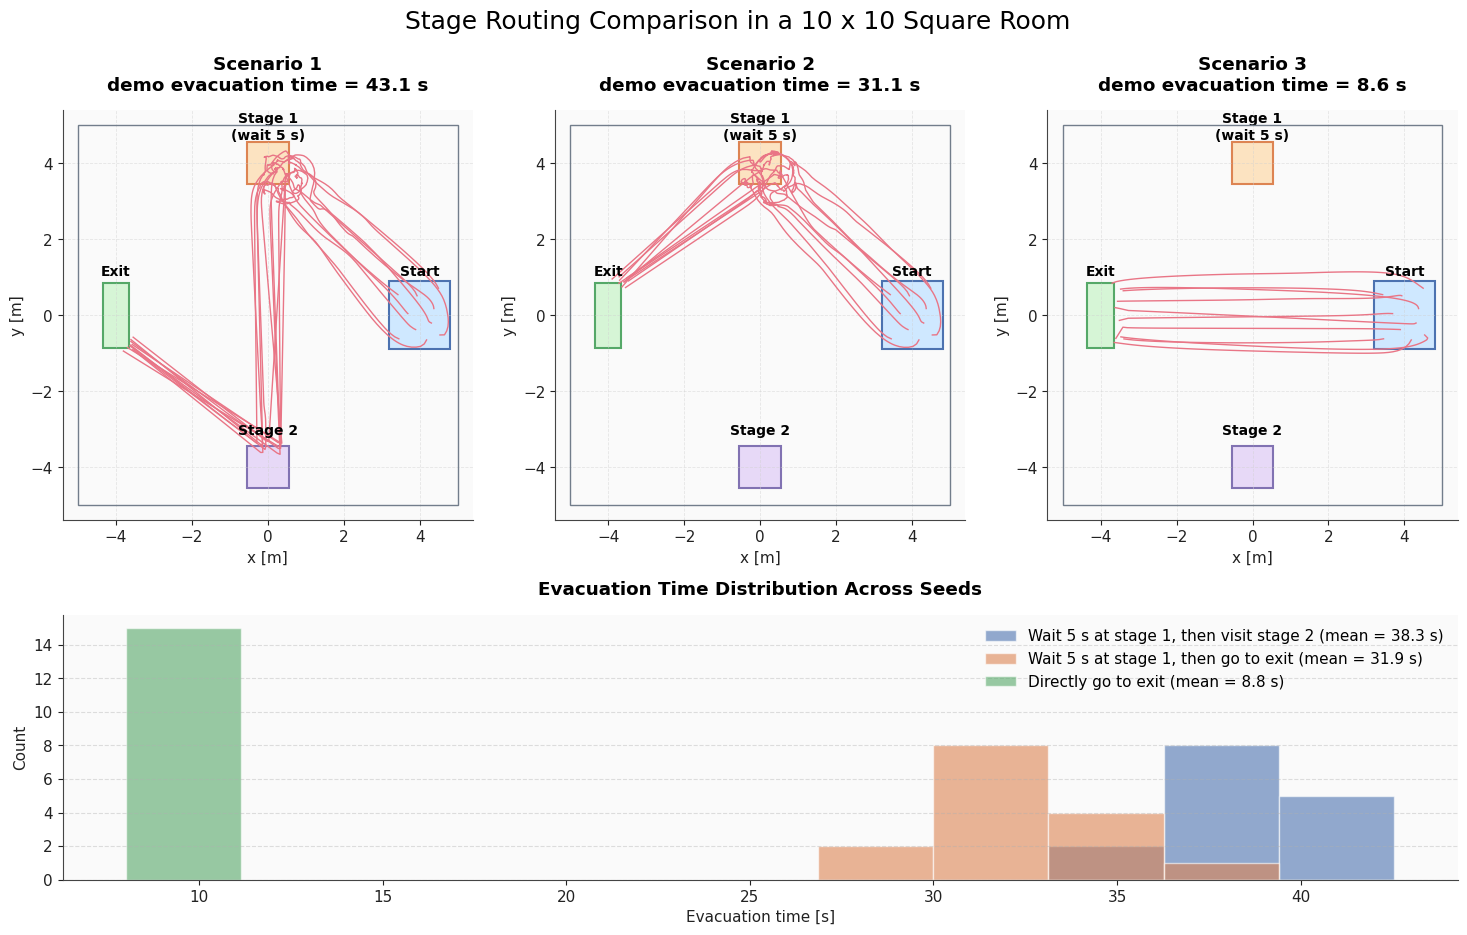

In [8]:
fig = plt.figure(figsize=(18, 10))
grid = fig.add_gridspec(2, 3, height_ratios=[1.4, 0.9], hspace=0.28)

for col, name in enumerate(["scenario_1", "scenario_2", "scenario_3"]):
    ax = fig.add_subplot(grid[0, col])
    pedpy.plot_trajectories(
        traj=results[name]["demo_traj"],
        walkable_area=walkable_area,
        axes=ax,
        alpha=0.75,
        linewidth=0.8,
        color=COLORS[name],
    ).set_aspect("equal")
    add_room_markers(ax)
    ax.set_title(
        f"{name.replace('_', ' ').title()}\n"
        f"demo evacuation time = {results[name]['demo_metrics']['evacuation_time']:.1f} s",
        pad=14,
    )

hist_ax = fig.add_subplot(grid[1, :])
bins = np.linspace(
    min(result["evac_times"].min() for result in results.values()) - 0.5,
    max(result["evac_times"].max() for result in results.values()) + 0.5,
    12,
)

for name in ["scenario_1", "scenario_2", "scenario_3"]:
    evac_times = results[name]["evac_times"]
    hist_ax.hist(
        evac_times,
        bins=bins,
        color=COLORS[name],
        alpha=0.6,
        edgecolor="white",
        linewidth=1.0,
        label=f"{LABELS[name]} (mean = {evac_times.mean():.1f} s)",
    )

hist_ax.set_title("Evacuation Time Distribution Across Seeds", pad=15)
hist_ax.set_xlabel("Evacuation time [s]")
hist_ax.set_ylabel("Count")
hist_ax.grid(axis="y", linestyle="--", alpha=0.4)
hist_ax.spines["top"].set_visible(False)
hist_ax.spines["right"].set_visible(False)
hist_ax.legend(frameon=False, ncol=1, loc="upper right")

fig.suptitle("Stage Routing Comparison in a 10 x 10 Square Room", fontsize=18, y=0.98)
plt.show()